In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
performance_table = pd.read_csv(
    "performance_table.csv",
    index_col=0
)

performance_table

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667


In [3]:
performance_table.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, Minimum Variance to Nifty 50
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Annual Return      4 non-null      float64
 1   Annual Volatility  4 non-null      float64
 2   Sharpe Ratio       4 non-null      float64
 3   Maximum Drawdown   4 non-null      float64
dtypes: float64(4)
memory usage: 160.0+ bytes


In [4]:
performance_table = performance_table.apply(pd.to_numeric)

In [5]:
performance_table

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667


In [6]:
highest_return = performance_table["Annual Return"].idxmax()
highest_return_value = performance_table["Annual Return"].max()

print("Highest annual return:", highest_return)
print(f"Return: {highest_return_value:.2%}")

Highest annual return: Equal Weight
Return: 19.30%


In [7]:
return_comparison = performance_table[
    ["Annual Return"]
].sort_values(
    "Annual Return",
    ascending=False
)

return_comparison

,Annual Return
Equal Weight,0.193013
Nifty 50,0.131303
Minimum Variance,0.124331
Maximum Sharpe,0.082764


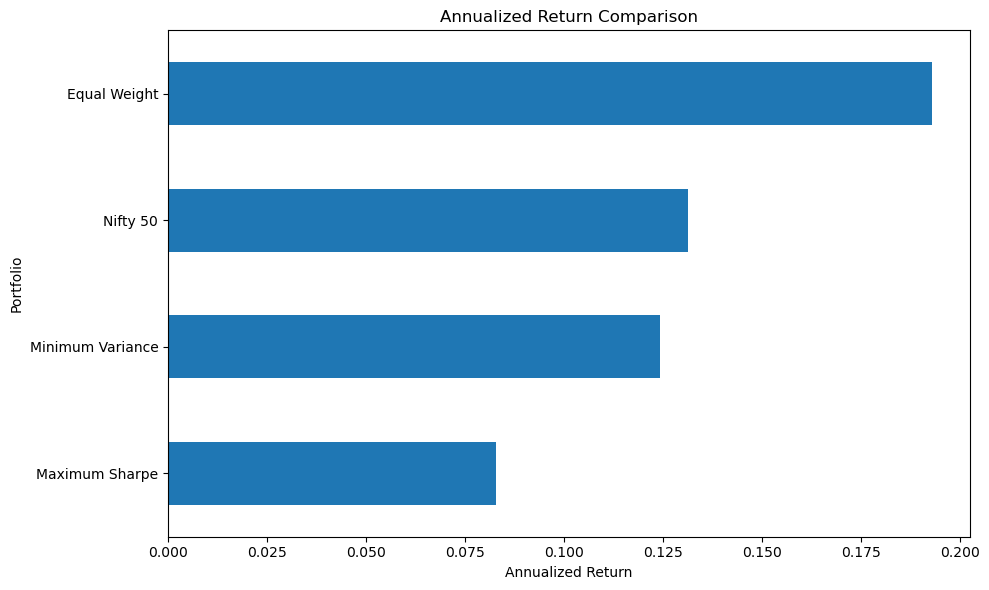

In [8]:
plt.figure(figsize=(10, 6))

performance_table["Annual Return"].sort_values().plot(
    kind="barh"
)

plt.title("Annualized Return Comparison")
plt.xlabel("Annualized Return")
plt.ylabel("Portfolio")

plt.tight_layout()
plt.show()

In [9]:
volatility_comparison = performance_table[
    ["Annual Volatility"]
].sort_values(
    "Annual Volatility"
)

volatility_comparison

,Annual Volatility
Minimum Variance,0.111355
Equal Weight,0.119530
Nifty 50,0.120165
Maximum Sharpe,0.124806


In [10]:
lowest_volatility = performance_table["Annual Volatility"].idxmin()
lowest_volatility_value = performance_table["Annual Volatility"].min()

print("Lowest volatility:", lowest_volatility)
print(f"Volatility: {lowest_volatility_value:.2%}")

Lowest volatility: Minimum Variance
Volatility: 11.14%


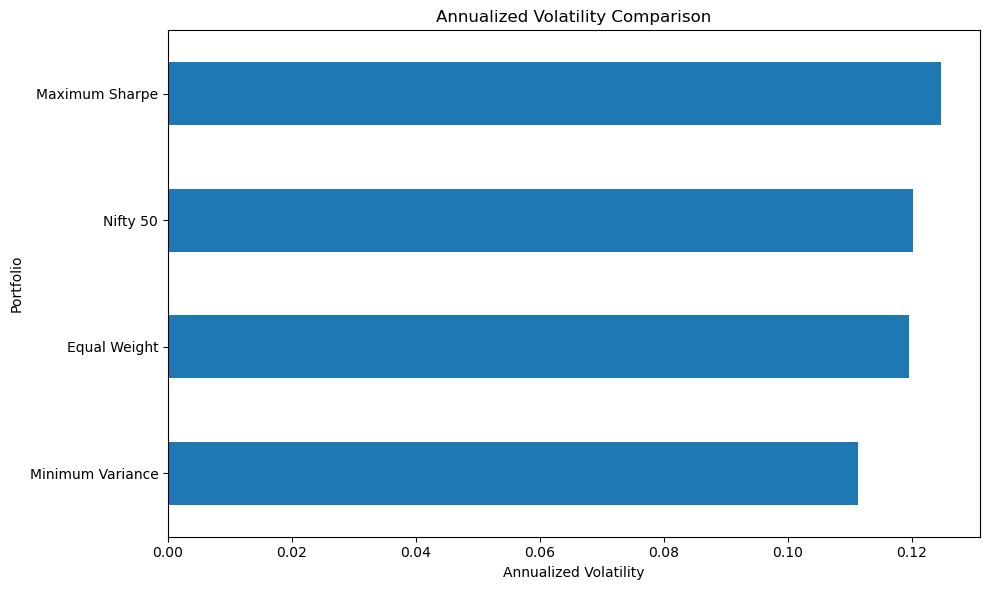

In [11]:
plt.figure(figsize=(10, 6))

performance_table["Annual Volatility"].sort_values().plot(
    kind="barh"
)

plt.title("Annualized Volatility Comparison")
plt.xlabel("Annualized Volatility")
plt.ylabel("Portfolio")

plt.tight_layout()
plt.show()

In [12]:
sharpe_comparison = performance_table[
    ["Sharpe Ratio"]
].sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe_comparison

,Sharpe Ratio
Equal Weight,1.112801
Nifty 50,0.593373
Minimum Variance,0.577712
Maximum Sharpe,0.182397


In [13]:
highest_sharpe = performance_table["Sharpe Ratio"].idxmax()
highest_sharpe_value = performance_table["Sharpe Ratio"].max()

print("Highest Sharpe ratio:", highest_sharpe)
print(f"Sharpe ratio: {highest_sharpe_value:.2f}")

Highest Sharpe ratio: Equal Weight
Sharpe ratio: 1.11


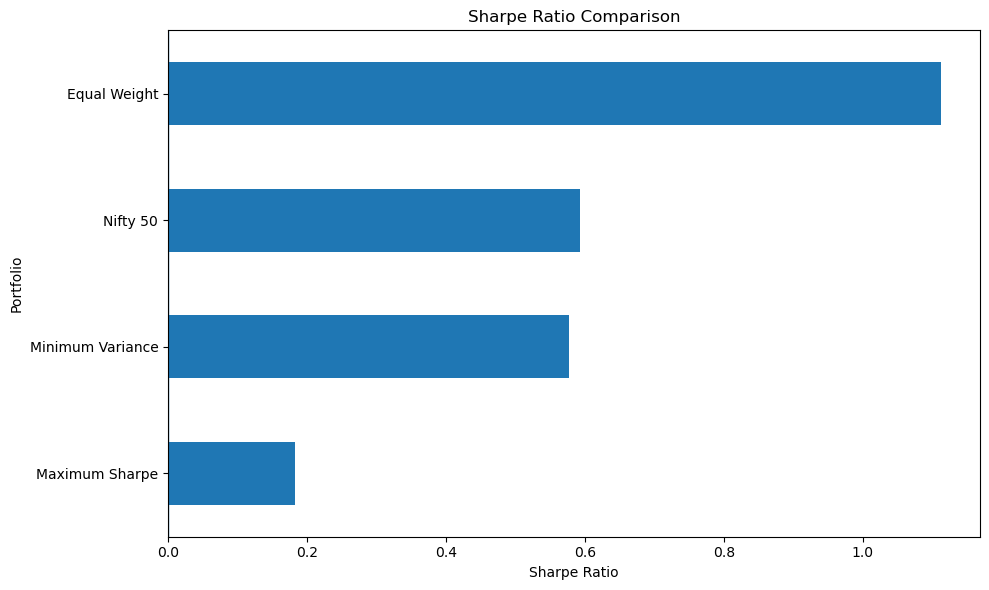

In [14]:
plt.figure(figsize=(10, 6))

performance_table["Sharpe Ratio"].sort_values().plot(
    kind="barh"
)

plt.axvline(0, linewidth=1)

plt.title("Sharpe Ratio Comparison")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Portfolio")

plt.tight_layout()
plt.show()

In [15]:
drawdown_comparison = performance_table[
    ["Maximum Drawdown"]
].sort_values(
    "Maximum Drawdown",
    ascending=False
)

drawdown_comparison

,Maximum Drawdown
Nifty 50,-0.157667
Equal Weight,-0.161291
Minimum Variance,-0.206221
Maximum Sharpe,-0.226535


In [16]:
smallest_drawdown = performance_table["Maximum Drawdown"].idxmax()
smallest_drawdown_value = performance_table["Maximum Drawdown"].max()

print("Smallest maximum drawdown:", smallest_drawdown)
print(f"Drawdown: {smallest_drawdown_value:.2%}")

Smallest maximum drawdown: Nifty 50
Drawdown: -15.77%


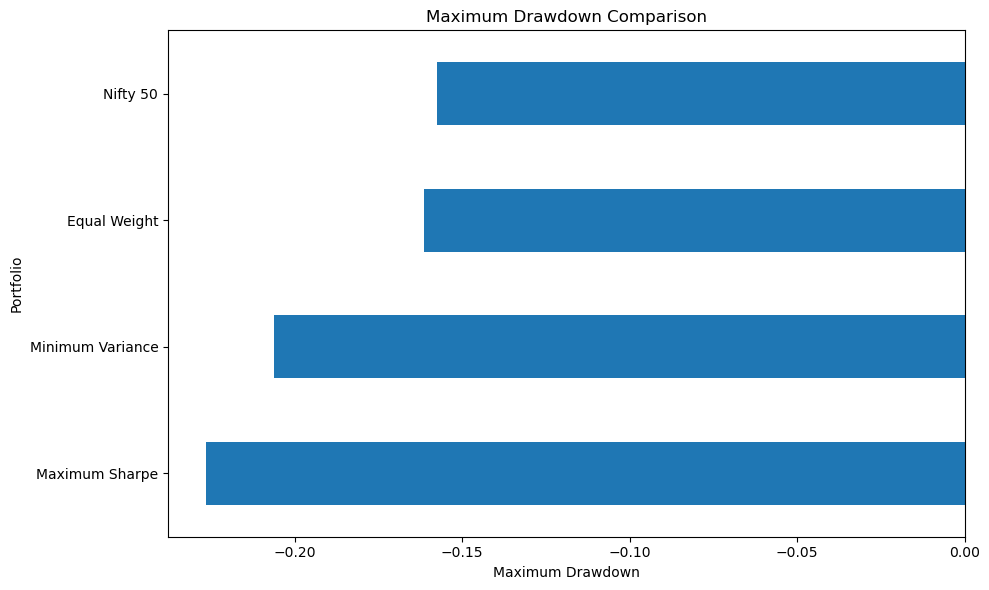

In [17]:
plt.figure(figsize=(10, 6))

performance_table["Maximum Drawdown"].sort_values().plot(
    kind="barh"
)

plt.title("Maximum Drawdown Comparison")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Portfolio")

plt.tight_layout()
plt.show()

In [18]:
performance_table.round(4)

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.1243,0.1114,0.5777,-0.2062
Maximum Sharpe,0.0828,0.1248,0.1824,-0.2265
Equal Weight,0.1930,0.1195,1.1128,-0.1613
Nifty 50,0.1313,0.1202,0.5934,-0.1577


In [19]:
performance_display = performance_table.copy()

performance_display["Annual Return"] = (
    performance_display["Annual Return"] * 100
).round(2)

performance_display["Annual Volatility"] = (
    performance_display["Annual Volatility"] * 100
).round(2)

performance_display["Maximum Drawdown"] = (
    performance_display["Maximum Drawdown"] * 100
).round(2)

performance_display["Sharpe Ratio"] = (
    performance_display["Sharpe Ratio"]
).round(2)

performance_display

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,12.43,11.14,0.58,-20.62
Maximum Sharpe,8.28,12.48,0.18,-22.65
Equal Weight,19.30,11.95,1.11,-16.13
Nifty 50,13.13,12.02,0.59,-15.77


In [20]:
equal_weight_return = performance_table.loc[
    "Equal Weight",
    "Annual Return"
]

equal_weight_sharpe = performance_table.loc[
    "Equal Weight",
    "Sharpe Ratio"
]

equal_weight_volatility = performance_table.loc[
    "Equal Weight",
    "Annual Volatility"
]

In [21]:
comparison = performance_table.copy()

comparison["Return vs Equal Weight"] = (
    comparison["Annual Return"]
    - equal_weight_return
)

comparison["Sharpe vs Equal Weight"] = (
    comparison["Sharpe Ratio"]
    - equal_weight_sharpe
)

comparison["Volatility vs Equal Weight"] = (
    comparison["Annual Volatility"]
    - equal_weight_volatility
)

comparison

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Return vs Equal Weight,Sharpe vs Equal Weight,Volatility vs Equal Weight
Minimum Variance,0.124331,0.111355,0.577712,-0.206221,-0.068682,-0.535088,-0.008175
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535,-0.110249,-0.930404,0.005276
Equal Weight,0.193013,0.119530,1.112801,-0.161291,0.000000,0.000000,0.000000
Nifty 50,0.131303,0.120165,0.593373,-0.157667,-0.061710,-0.519427,0.000635


In [22]:
nifty_return = performance_table.loc[
    "Nifty 50",
    "Annual Return"
]

nifty_sharpe = performance_table.loc[
    "Nifty 50",
    "Sharpe Ratio"
]

nifty_volatility = performance_table.loc[
    "Nifty 50",
    "Annual Volatility"
]

In [23]:
optimization_vs_nifty = performance_table.copy()

optimization_vs_nifty["Return vs Nifty"] = (
    optimization_vs_nifty["Annual Return"]
    - nifty_return
)

optimization_vs_nifty["Sharpe vs Nifty"] = (
    optimization_vs_nifty["Sharpe Ratio"]
    - nifty_sharpe
)

optimization_vs_nifty["Volatility vs Nifty"] = (
    optimization_vs_nifty["Annual Volatility"]
    - nifty_volatility
)

optimization_vs_nifty

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Return vs Nifty,Sharpe vs Nifty,Volatility vs Nifty
Minimum Variance,0.124331,0.111355,0.577712,-0.206221,-0.006972,-0.015661,-0.008810
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535,-0.048539,-0.410977,0.004640
Equal Weight,0.193013,0.119530,1.112801,-0.161291,0.061710,0.519427,-0.000635
Nifty 50,0.131303,0.120165,0.593373,-0.157667,0.000000,0.000000,0.000000


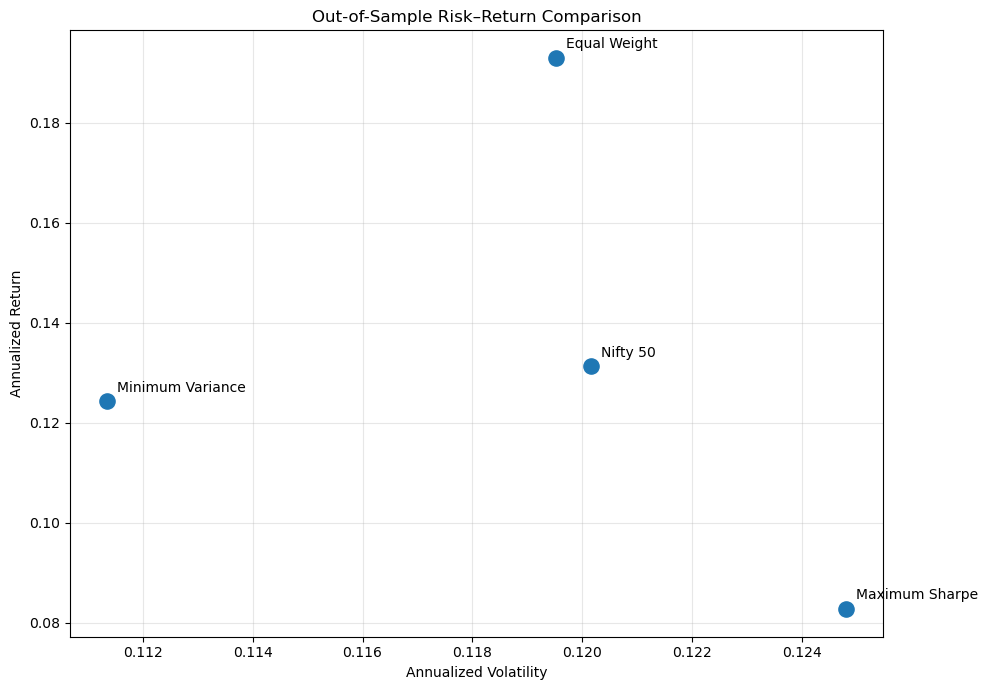

In [24]:
plt.figure(figsize=(10, 7))

plt.scatter(
    performance_table["Annual Volatility"],
    performance_table["Annual Return"],
    s=120
)

for portfolio in performance_table.index:
    plt.annotate(
        portfolio,
        (
            performance_table.loc[portfolio, "Annual Volatility"],
            performance_table.loc[portfolio, "Annual Return"]
        ),
        xytext=(7, 7),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Out-of-Sample Risk–Return Comparison")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
weights_table = pd.read_csv(
    "optimized_portfolio_weights.csv",
    index_col=0
)

weights_table

,Minimum Variance,Maximum Sharpe,Equal Weight
ASIANPAINT.NS,8.070003e-02,2.622899e-02,0.05
BHARTIARTL.NS,4.920305e-02,1.716278e-01,0.05
HDFCBANK.NS,1.195586e-01,1.058732e-02,0.05
HINDALCO.NS,1.094688e-18,8.123322e-03,0.05
HINDUNILVR.NS,1.705294e-01,7.846116e-02,0.05
ICICIBANK.NS,7.389409e-19,1.449764e-17,0.05
INFY.NS,4.309464e-02,1.089767e-01,0.05
ITC.NS,1.113993e-01,3.414197e-17,0.05
KOTAKBANK.NS,9.131831e-03,0.000000e+00,0.05
LT.NS,2.568173e-18,1.587058e-17,0.05


In [26]:
weights_table.sum()

Minimum Variance    1.0
Maximum Sharpe      1.0
Equal Weight        1.0
dtype: float64

In [27]:
for strategy in weights_table.columns:
    print(
        strategy,
        "total weight =",
        weights_table[strategy].sum()
    )

Minimum Variance total weight = 0.9999999999999992
Maximum Sharpe total weight = 0.999999999955193
Equal Weight total weight = 1.0000000000000002


In [28]:
min_var_weights = weights_table[
    "Minimum Variance"
].sort_values(
    ascending=False
)

min_var_weights.head(10)

HINDUNILVR.NS    0.170529
TCS.NS           0.150857
POWERGRID.NS     0.126836
HDFCBANK.NS      0.119559
ITC.NS           0.111399
SUNPHARMA.NS     0.087274
ASIANPAINT.NS    0.080700
NTPC.NS          0.049788
BHARTIARTL.NS    0.049203
INFY.NS          0.043095
Name: Minimum Variance, dtype: float64

In [29]:
max_sharpe_weights = weights_table[
    "Maximum Sharpe"
].sort_values(
    ascending=False
)

max_sharpe_weights.head(10)

RELIANCE.NS      0.227309
POWERGRID.NS     0.189455
BHARTIARTL.NS    0.171628
INFY.NS          0.108977
M&M.NS           0.101582
HINDUNILVR.NS    0.078461
MARUTI.NS        0.042008
TATASTEEL.NS     0.035640
ASIANPAINT.NS    0.026229
HDFCBANK.NS      0.010587
Name: Maximum Sharpe, dtype: float64

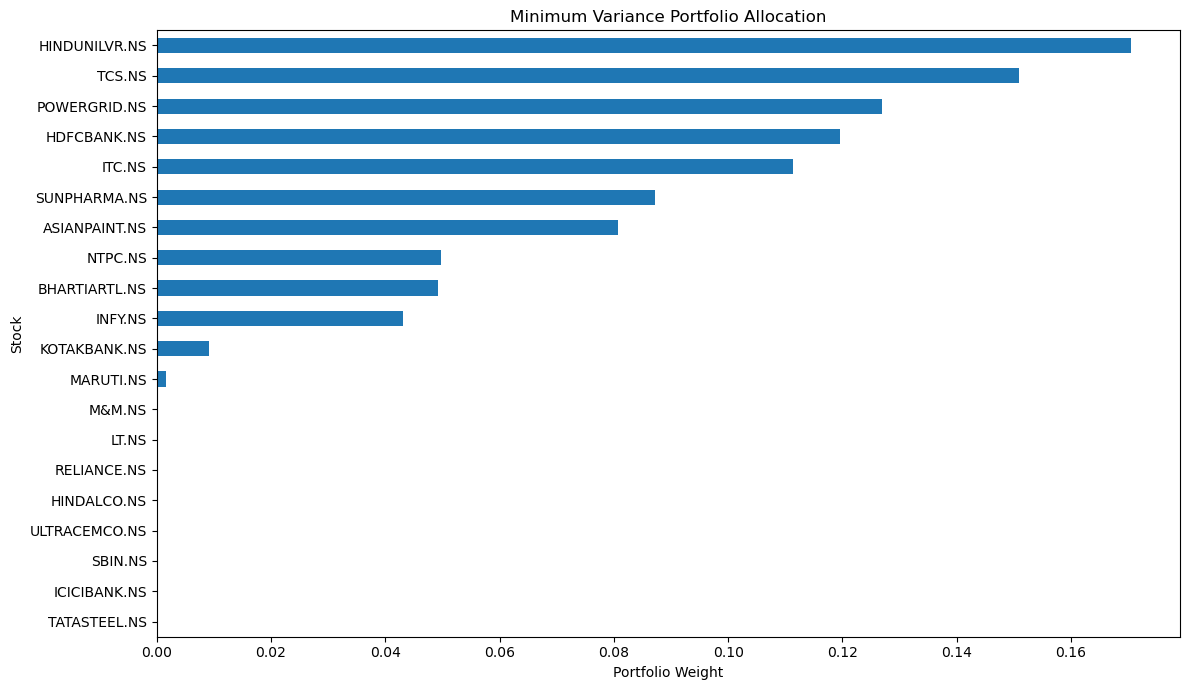

In [30]:
plt.figure(figsize=(12, 7))

min_var_weights.sort_values().plot(
    kind="barh"
)

plt.title("Minimum Variance Portfolio Allocation")
plt.xlabel("Portfolio Weight")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

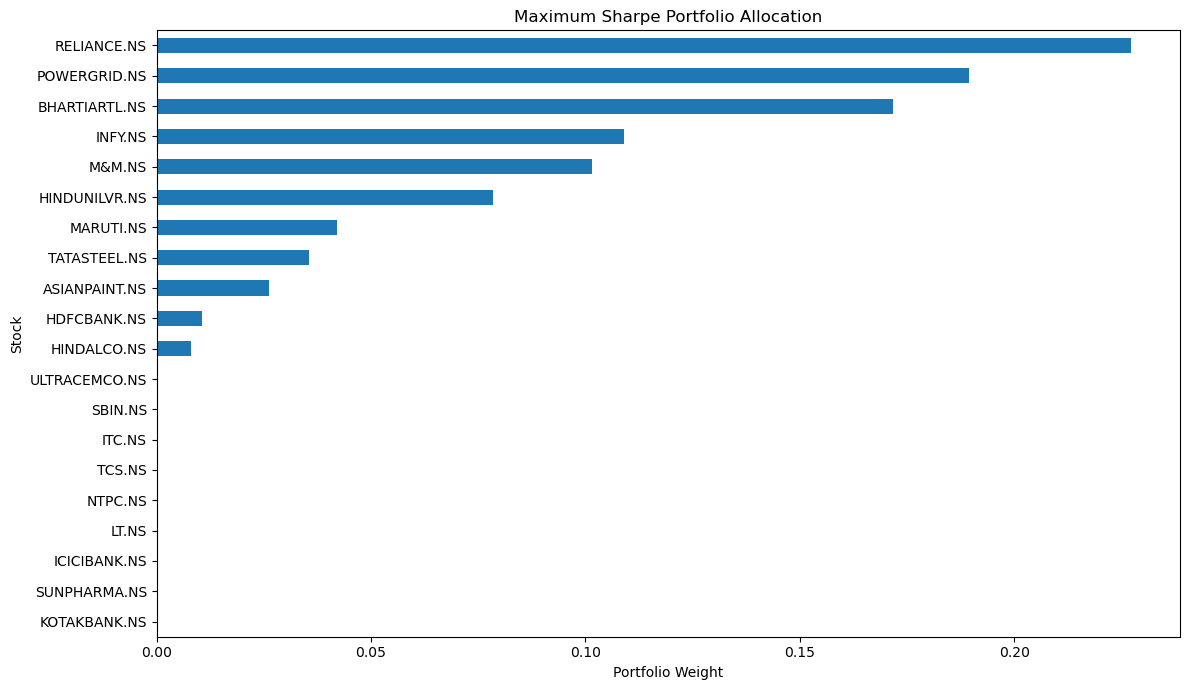

In [31]:
plt.figure(figsize=(12, 7))

max_sharpe_weights.sort_values().plot(
    kind="barh"
)

plt.title("Maximum Sharpe Portfolio Allocation")
plt.xlabel("Portfolio Weight")
plt.ylabel("Stock")

plt.tight_layout()
plt.show()

In [32]:
weight_comparison = weights_table[
    ["Minimum Variance", "Maximum Sharpe"]
].copy()

weight_comparison["Difference"] = (
    weight_comparison["Maximum Sharpe"]
    - weight_comparison["Minimum Variance"]
)

weight_comparison.sort_values(
    "Difference",
    ascending=False
)

,Minimum Variance,Maximum Sharpe,Difference
RELIANCE.NS,1.517883e-18,2.273088e-01,2.273088e-01
BHARTIARTL.NS,4.920305e-02,1.716278e-01,1.224247e-01
M&M.NS,3.334029e-18,1.015824e-01,1.015824e-01
INFY.NS,4.309464e-02,1.089767e-01,6.588203e-02
POWERGRID.NS,1.268363e-01,1.894550e-01,6.261862e-02
MARUTI.NS,1.627631e-03,4.200833e-02,4.038070e-02
TATASTEEL.NS,0.000000e+00,3.564033e-02,3.564033e-02
HINDALCO.NS,1.094688e-18,8.123322e-03,8.123322e-03
ULTRACEMCO.NS,1.048905e-18,4.567632e-17,4.462742e-17
SBIN.NS,9.874943e-19,3.604546e-17,3.505796e-17


In [33]:
def calculate_hhi(weights):
    return np.sum(weights ** 2)

In [34]:
hhi_results = {}

for portfolio in weights_table.columns:
    hhi_results[portfolio] = calculate_hhi(
        weights_table[portfolio].values
    )

hhi = pd.Series(hhi_results, name="HHI")

hhi

Minimum Variance    0.115602
Maximum Sharpe      0.149271
Equal Weight        0.050000
Name: HHI, dtype: float64

In [35]:
equal_weight_hhi = 1 / len(weights_table)

print("Equal-weight HHI:", equal_weight_hhi)

Equal-weight HHI: 0.05


In [36]:
hhi_comparison = pd.DataFrame({
    "HHI": hhi,
    "Equal Weight HHI": equal_weight_hhi
})

hhi_comparison

,HHI,Equal Weight HHI
Minimum Variance,0.115602,0.05
Maximum Sharpe,0.149271,0.05
Equal Weight,0.050000,0.05


In [37]:
effective_n = 1 / hhi

effective_n

Minimum Variance     8.650377
Maximum Sharpe       6.699244
Equal Weight        20.000000
Name: HHI, dtype: float64

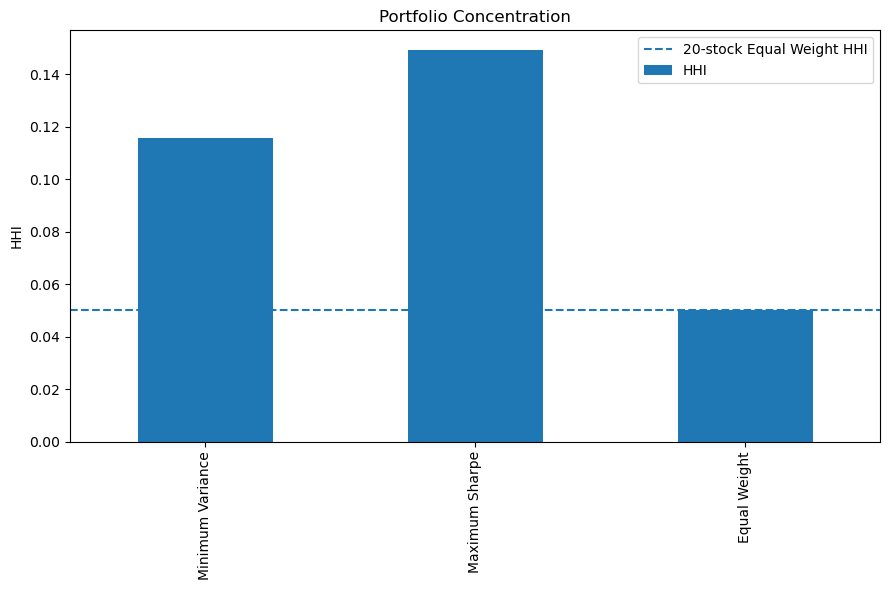

In [38]:
plt.figure(figsize=(9, 6))

hhi.plot(
    kind="bar"
)

plt.axhline(
    equal_weight_hhi,
    linestyle="--",
    label="20-stock Equal Weight HHI"
)

plt.title("Portfolio Concentration")
plt.ylabel("HHI")
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
sector_map = {
    "RELIANCE.NS": "Energy",
    "HDFCBANK.NS": "Financials",
    "ICICIBANK.NS": "Financials",
    "SBIN.NS": "Financials",
    "KOTAKBANK.NS": "Financials",
    "TCS.NS": "IT",
    "INFY.NS": "IT",
    "ITC.NS": "FMCG",
    "HINDUNILVR.NS": "FMCG",
    "SUNPHARMA.NS": "Healthcare",
    "BHARTIARTL.NS": "Telecom",
    "LT.NS": "Industrials",
    "M&M.NS": "Automobiles",
    "MARUTI.NS": "Automobiles",
    "ASIANPAINT.NS": "Consumer/Materials",
    "ULTRACEMCO.NS": "Construction Materials",
    "NTPC.NS": "Power",
    "POWERGRID.NS": "Power",
    "TATASTEEL.NS": "Metals",
    "HINDALCO.NS": "Metals"
}

In [40]:
weights_table["Sector"] = [
    sector_map[stock]
    for stock in weights_table.index
]

weights_table

,Minimum Variance,Maximum Sharpe,Equal Weight,Sector
ASIANPAINT.NS,8.070003e-02,2.622899e-02,0.05,Consumer/Materials
BHARTIARTL.NS,4.920305e-02,1.716278e-01,0.05,Telecom
HDFCBANK.NS,1.195586e-01,1.058732e-02,0.05,Financials
HINDALCO.NS,1.094688e-18,8.123322e-03,0.05,Metals
HINDUNILVR.NS,1.705294e-01,7.846116e-02,0.05,FMCG
ICICIBANK.NS,7.389409e-19,1.449764e-17,0.05,Financials
INFY.NS,4.309464e-02,1.089767e-01,0.05,IT
ITC.NS,1.113993e-01,3.414197e-17,0.05,FMCG
KOTAKBANK.NS,9.131831e-03,0.000000e+00,0.05,Financials
LT.NS,2.568173e-18,1.587058e-17,0.05,Industrials


In [41]:
sector_weights = weights_table.groupby(
    "Sector"
)[
    ["Minimum Variance", "Maximum Sharpe", "Equal Weight"]
].sum()

sector_weights

,Minimum Variance,Maximum Sharpe,Equal Weight
Sector,,,
Automobiles,1.627631e-03,1.435907e-01,0.10
Construction Materials,1.048905e-18,4.567632e-17,0.05
Consumer/Materials,8.070003e-02,2.622899e-02,0.05
Energy,1.517883e-18,2.273088e-01,0.05
FMCG,2.819287e-01,7.846116e-02,0.10
Financials,1.286905e-01,1.058732e-02,0.20
Healthcare,8.727424e-02,8.048585e-18,0.05
IT,1.939517e-01,1.089767e-01,0.10
Industrials,2.568173e-18,1.587058e-17,0.05


In [42]:
sector_weights.sum()

Minimum Variance    1.0
Maximum Sharpe      1.0
Equal Weight        1.0
dtype: float64

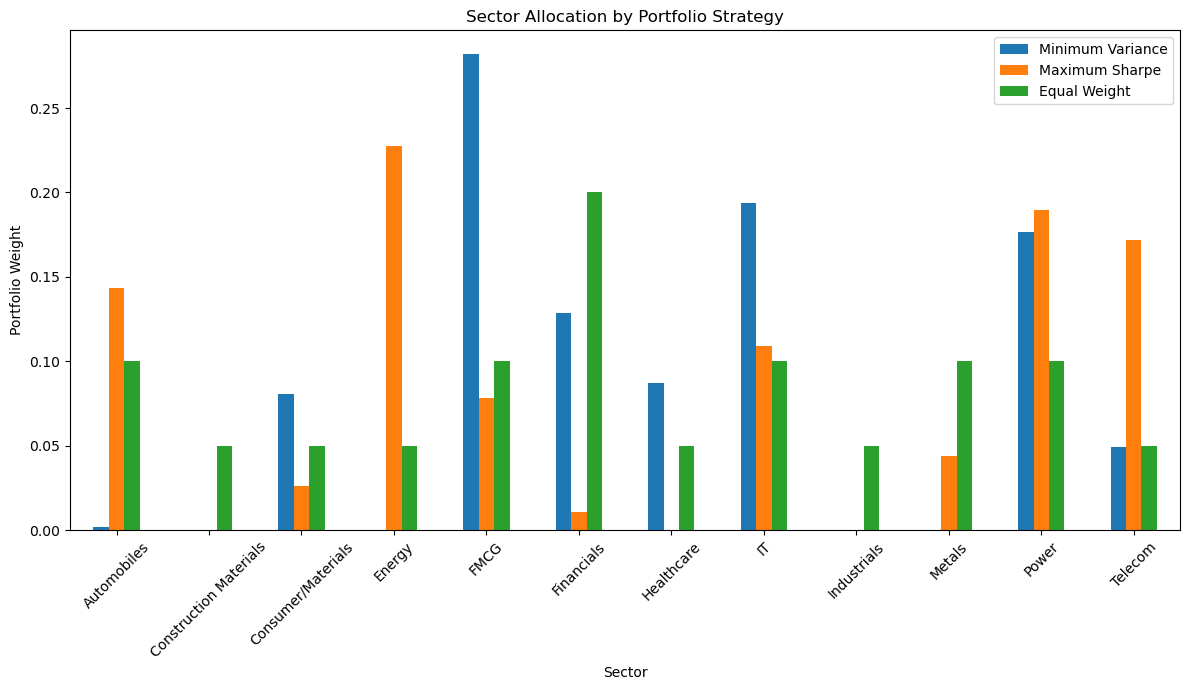

In [43]:
sector_weights.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Sector Allocation by Portfolio Strategy")
plt.xlabel("Sector")
plt.ylabel("Portfolio Weight")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
for portfolio in [
    "Minimum Variance",
    "Maximum Sharpe",
    "Equal Weight"
]:
    
    print("\n", portfolio)
    
    print(
        sector_weights[portfolio]
        .sort_values(ascending=False)
        .head(5)
    )


 Minimum Variance
Sector
FMCG          0.281929
IT            0.193952
Power         0.176624
Financials    0.128690
Healthcare    0.087274
Name: Minimum Variance, dtype: float64

 Maximum Sharpe
Sector
Energy         0.227309
Power          0.189455
Telecom        0.171628
Automobiles    0.143591
IT             0.108977
Name: Maximum Sharpe, dtype: float64

 Equal Weight
Sector
Financials     0.2
Automobiles    0.1
FMCG           0.1
IT             0.1
Metals         0.1
Name: Equal Weight, dtype: float64


In [45]:
sector_hhi = {}

for portfolio in [
    "Minimum Variance",
    "Maximum Sharpe",
    "Equal Weight"
]:
    
    sector_hhi[portfolio] = np.sum(
        sector_weights[portfolio] ** 2
    )

sector_hhi = pd.Series(
    sector_hhi,
    name="Sector HHI"
)

sector_hhi

Minimum Variance    0.181411
Maximum Sharpe      0.158384
Equal Weight        0.105000
Name: Sector HHI, dtype: float64

In [46]:
frontier_df = pd.read_csv(
    "efficient_frontier.csv"
)

frontier_df.head()

,Target Return,Volatility
0,0.165441,0.136235
1,0.167399,0.136287
2,0.169358,0.136404
3,0.171316,0.136585
4,0.173275,0.136832


In [47]:
frontier_df.columns

Index(['Target Return', 'Volatility'], dtype='object')

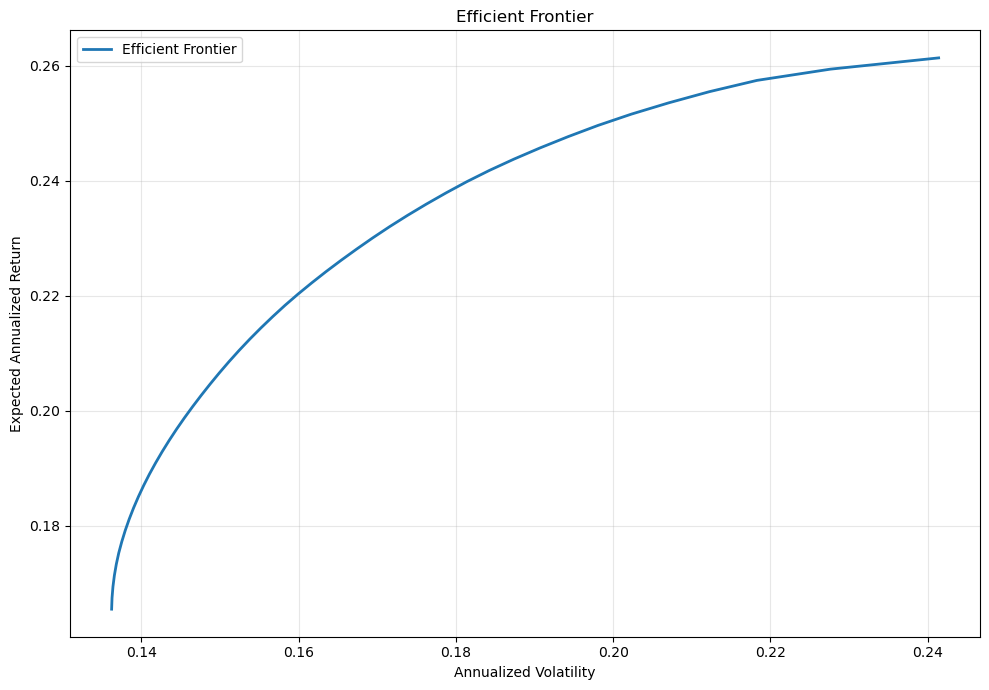

In [48]:
plt.figure(figsize=(10, 7))

plt.plot(
    frontier_df["Volatility"],
    frontier_df["Target Return"],
    linewidth=2,
    label="Efficient Frontier"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annualized Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
expected_returns = pd.read_csv(
    "risk_return_summary.csv",
    index_col=0
)

In [50]:
expected_returns_vector = (
    expected_returns["Annualized Return (%)"] / 100
)

In [51]:
cov_matrix = pd.read_csv(
    "annualized_covariance_matrix.csv",
    index_col=0
)

cov_matrix = cov_matrix.loc[
    weights_table.index,
    weights_table.index
]

In [52]:
def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, cov_matrix):
    variance = weights.T @ cov_matrix.values @ weights
    return np.sqrt(variance)

In [53]:
portfolio_points = {}

for portfolio in [
    "Minimum Variance",
    "Maximum Sharpe",
    "Equal Weight"
]:
    
    weights = weights_table[portfolio].values
    
    ret = portfolio_return(
        weights,
        expected_returns_vector.loc[weights_table.index].values
    )
    
    vol = portfolio_volatility(
        weights,
        cov_matrix
    )
    
    portfolio_points[portfolio] = {
        "Return": ret,
        "Volatility": vol
    }

portfolio_points = pd.DataFrame(portfolio_points).T

portfolio_points

,Return,Volatility
Minimum Variance,0.165441,0.136231
Maximum Sharpe,0.226372,0.165609
Equal Weight,0.196376,0.161986


In [54]:
results_df = pd.read_pickle(
    "random_portfolios.pkl"
)

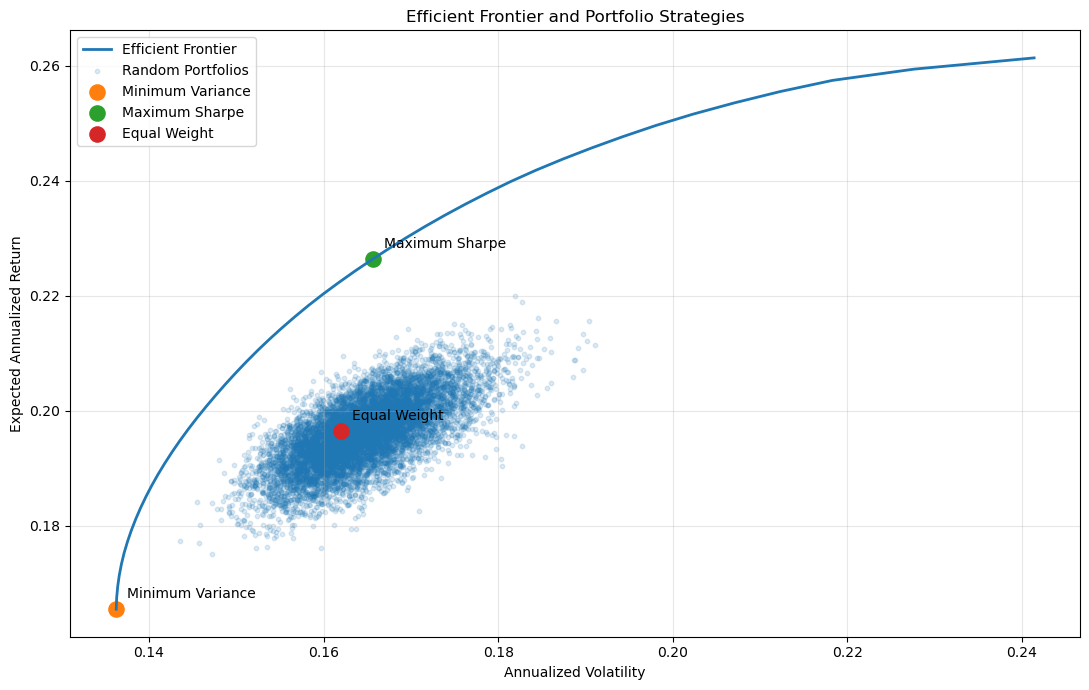

In [55]:
plt.figure(figsize=(11, 7))

# Efficient frontier
plt.plot(
    frontier_df["Volatility"],
    frontier_df["Target Return"],
    linewidth=2,
    label="Efficient Frontier"
)

# Random portfolios
plt.scatter(
    results_df["Volatility"],
    results_df["Return"],
    alpha=0.15,
    s=10,
    label="Random Portfolios"
)

# Optimized portfolios
for portfolio in portfolio_points.index:
    
    plt.scatter(
        portfolio_points.loc[portfolio, "Volatility"],
        portfolio_points.loc[portfolio, "Return"],
        s=120,
        label=portfolio
    )

    plt.annotate(
        portfolio,
        (
            portfolio_points.loc[portfolio, "Volatility"],
            portfolio_points.loc[portfolio, "Return"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Annualized Volatility")
plt.ylabel("Expected Annualized Return")
plt.title("Efficient Frontier and Portfolio Strategies")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
print("===== RESEARCH FINDINGS =====\n")

# Highest return
best_return = performance_table["Annual Return"].idxmax()

print(
    f"1. Highest realized annual return: "
    f"{best_return} "
    f"({performance_table.loc[best_return, 'Annual Return']:.2%})"
)

# Lowest volatility
lowest_vol = performance_table["Annual Volatility"].idxmin()

print(
    f"2. Lowest realized volatility: "
    f"{lowest_vol} "
    f"({performance_table.loc[lowest_vol, 'Annual Volatility']:.2%})"
)

# Highest Sharpe
best_sharpe = performance_table["Sharpe Ratio"].idxmax()

print(
    f"3. Highest realized Sharpe ratio: "
    f"{best_sharpe} "
    f"({performance_table.loc[best_sharpe, 'Sharpe Ratio']:.2f})"
)

# Best drawdown
best_drawdown = performance_table["Maximum Drawdown"].idxmax()

print(
    f"4. Smallest maximum drawdown: "
    f"{best_drawdown} "
    f"({performance_table.loc[best_drawdown, 'Maximum Drawdown']:.2%})"
)

# Maximum Sharpe vs Equal Weight
ms_return = performance_table.loc[
    "Maximum Sharpe",
    "Annual Return"
]

ew_return = performance_table.loc[
    "Equal Weight",
    "Annual Return"
]

print(
    f"\n5. Maximum Sharpe vs Equal Weight: "
    f"{'Outperformed' if ms_return > ew_return else 'Underperformed'} "
    f"on annual return."
)

# Maximum Sharpe vs Nifty
nifty_return = performance_table.loc[
    "Nifty 50",
    "Annual Return"
]

print(
    f"6. Maximum Sharpe vs Nifty 50: "
    f"{'Outperformed' if ms_return > nifty_return else 'Underperformed'} "
    f"on annual return."
)

# Minimum variance volatility
mv_vol = performance_table.loc[
    "Minimum Variance",
    "Annual Volatility"
]

print(
    f"7. Minimum Variance achieved "
    f"{mv_vol:.2%} realized annual volatility."
)

# Concentration
print("\n8. Portfolio concentration (HHI):")

for portfolio, value in hhi.items():
    print(
        f"   {portfolio}: {value:.4f} "
        f"(effective stocks ≈ {1/value:.1f})"
    )

===== RESEARCH FINDINGS =====

1. Highest realized annual return: Equal Weight (19.30%)
2. Lowest realized volatility: Minimum Variance (11.14%)
3. Highest realized Sharpe ratio: Equal Weight (1.11)
4. Smallest maximum drawdown: Nifty 50 (-15.77%)

5. Maximum Sharpe vs Equal Weight: Underperformed on annual return.
6. Maximum Sharpe vs Nifty 50: Underperformed on annual return.
7. Minimum Variance achieved 11.14% realized annual volatility.

8. Portfolio concentration (HHI):
   Minimum Variance: 0.1156 (effective stocks ≈ 8.7)
   Maximum Sharpe: 0.1493 (effective stocks ≈ 6.7)
   Equal Weight: 0.0500 (effective stocks ≈ 20.0)


In [57]:
sector_weights.to_csv(
    "sector_weights.csv"
)

print("sector_weights.csv saved successfully.")

sector_weights.csv saved successfully.
